# Analyzing Maternal Health Risk Data

Rin Hwang 

Data 101

May 3, 2026

## Introduction

In this project, I explored a Maternal Health Risk dataset that contains data collected from various hospitals, community clinics and maternal health cares from the rural areas of Bangladesh. The research question I am investigating is: 

"Does systolic blood pressure (SystolicBP) or blood glucose levels (BS) serve as the more significant predictor for 'High Risk' classifications in pregnant women?" 

This analysis identifies the primary physiological factors of severe maternal health complications. Specifically, this research evaluates whether Systolic Blood Pressure or Blood Glucose levels serves as a more significant predictor for "High Risk" classifications in pregnant women. By identifying which clinical indicator holds greater predictive signifigance, the results can allow health care providers to better prioritize monitoring protocols for at-risk patients, and improving intervention in maternal care.

The source of this data comes from the University of California, Irvine Machine Learning Repository. This dataset is uniquely appropriate for this research question because it contains clinical vitals linked directly to a professional medical assessment of risk. 

Link to dataset: https://archive.ics.uci.edu/dataset/863/maternal+health+risk

The dataset has 7 variables: 

- "Age": A quantitative variable for the age of the patient in years.

- "SystolicBP": A quantitative variable measuring the upper value of blood pressure (mmHg) in arteries.

- "DiastolicBP": A quantitative variable measuring the lower value of blood pressure (mmHg).

- "BS": A quantitative variable measuring blood glucose levels (mmol/L).

- "BodyTemp": A quantitative variable measuring the body temperature in Fahrenheit.

- "HeartRate" A quantitative variable measuring the resting heart rate (bpm).

- "RiskLevel" (Target variable): The categorical indicator for risk level (Low, Mid, High).

## Supervised Learning

To conduct the supervised learning, the dataset was first cleaned and the 3 categorical risk levels were encoded to 0, 1, and 2. The feature variables were then standardized using StandardScaler to ensure all vital signs were on a comparable scale before using it in a logistic regression model. The model's performance was evaluated by calculating the coefficients for each feature to determine predictor significance, alongside metrics like Accuracy and Log Loss to measure overall classification success.

## Conclusion and Future Directions

The results and analysis successfully identifies Blood Sugar (BS) as the more significant predictor for 'High Risk' classifications in pregnant women. 
With a standardized coefficient of 1.23, Blood Sugar's predictive weight nearly triples that of Systolic Blood Pressure, 0.44. This finding is critical because it suggests that metabolic dysfunction may be a more sensitive indicator of maternal issues than conventional cardiovascular metrics in this population. While cardiovascular metrics like blood pressure and heart rate do contribute to the model, they are secondary to metabolic markers. Additionally, while the original model achieved 62.4% accuracy, the PCA showed that even when reducing the number of variables and having fewer dimensions, there would only be a minimal impact on performance and still retain most of its predictive power. This demostrates that while maternal health is multidimensional, a significant portion of risk can be summarized through a reduced set of transformed variables. 

In the scree plot visualization, it is apparent that the first principal component (PC1) is the most dominant, accounting for 43.5% of the total variance which likely represents the primary influence of blood sugar and blood pressure. While the first two components capture a combined 62.5% of the variance, the plot ultimately suggests that four components are necessary to reach an 88.3% cumulative variance threshold. This indicates that while dimensionality reduction is effective, 4 components is the most balanced choice for retaining the critical clinical signals needed to predict high-risk outcomes accurately. 

These results are meaningful because they prioritize glucose monitoring as a primary intervention for preventing high-risk complications. This could potentially help shift the focus of routine prenatal screenings. By showing that using 6 different health measurements into just four components without losing much accuracy, it reveals the capacity that remote monitoring tools can be made simpler and more efficient by focusing only on the most important data patterns. Future research could utilize longitudinal studies analyzing the rate of change in these vitals over the course of a pregnancy from all stages and trimesters as it could provide more accurate early warning signals and systems for hospitals and clinics. It would also be interesting to look at similar data from different countries to see if there are factors beyond purely physiological ones that affect high-risk pregnancies.

## References

Ahmed, M. (2020). Maternal Health Risk [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DP5D.

## Code

### Importing libraries and dataset

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss,confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA

In [147]:
df = pd.read_csv("C:/Users/hwang/OneDrive/Documents/MC stuff/Spring 2026/DATA 101 Introduction to Data Science/Projects/Project 3/Maternal Health Risk Data Set.csv")

### Getting variable info

In [148]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


### Data Selection and Encoding

I selected and encoded the target variables to: 

0 = low risk 

1 = mid risk 

2 = high risk

### Using Supervised Learning

In [150]:
# Encoding and making column to string and lowercase it
risk_encode = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel'] = df['RiskLevel'].astype(str).str.lower().str.strip().map(risk_encode)

# Drop any rows where invalid
df = df.dropna(subset=['RiskLevel'])

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel'].astype(int)

#### Original Feature Analysis

In [151]:
# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train model
model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X_scaled, y)

# Significance for "High Risk"
high_risk = pd.DataFrame({
    'Feature': X.columns, 
    'Coefficient': model.coef_[2]
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Significance for High Risk Category ---")
print(high_risk)


--- Significance for High Risk Category ---
       Feature  Coefficient
3           BS     1.228875
4     BodyTemp     0.547336
1   SystolicBP     0.439707
2  DiastolicBP     0.374345
5    HeartRate     0.284582
0          Age    -0.148912


In [152]:
# Evaluation of original model
y_prob = model.predict_proba(X_scaled)

print(f"Original Model Accuracy: {model.score(X_scaled, y):.4f}")
print(f"Original Model Log Loss: {log_loss(y, y_prob):.4f}")

Original Model Accuracy: 0.6243
Original Model Log Loss: 0.7701


#### Dimensionality Reduction via PCA Analysis

In [153]:
pca = PCA()
score = pca.fit_transform(X_scaled)

# Calculating Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio per Component:", explained_variance)
print("Cumulative Variance:", cumulative_variance)

pca_df = pd.DataFrame(data=score[:,:2], columns=['PC1', 'PC2'])
pca_df['Target'] = df['RiskLevel'].values

Explained Variance Ratio per Component: [0.4346489  0.1907302  0.13950832 0.11772242 0.08209058 0.03529959]
Cumulative Variance: [0.4346489  0.6253791  0.76488741 0.88260984 0.96470041 1.        ]


In [154]:
# Evaluation of PCA model
y_prob_pca = model_pca.predict_proba(X_pca)

print(f"PCA Model Accuracy: {model_pca.score(X_pca, y):.4f}")

PCA Model Accuracy: 0.5848


### Visualization

Creating a scree plot to plot the justification

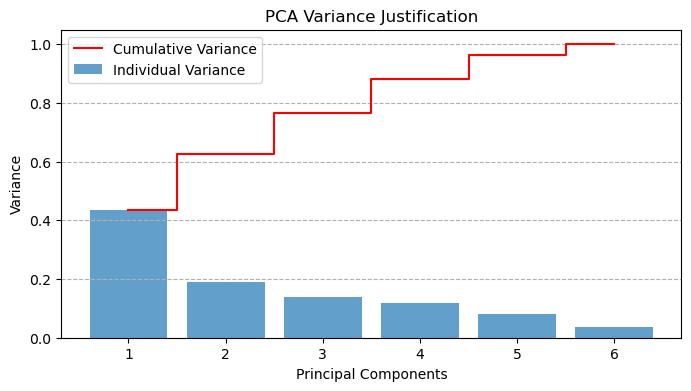

In [155]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, 7), explained_variance, alpha=0.7, label='Individual Variance')
plt.step(range(1, 7), cumulative_variance, where='mid', label='Cumulative Variance', color='red')
plt.xlabel('Principal Components')
plt.ylabel('Variance')
plt.title('PCA Variance Justification')
plt.legend()
plt.grid(axis='y', linestyle='--')